# M3: LLM Benchmark (Zero-Shot Inference)

V tomto notebooku porovnáme výkon našich natrénovaných modelů (Logistic Regression, Mahalanobis) s moderními Large Language Models (LLM) v režimu Zero-Shot.

## 1. Setup & Imports

In [1]:
import sys
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, accuracy_score


# Auto-reload modules for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Add src to path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Import custom modules
import config
import data_splitting
import models
import visualization
import experiments
import evaluation
from llm_client import LLMClassifier

# Setup visualization style
visualization.setup_style()

print(f"✅ Setup complete. Data dir: {config.DATA_DIR}")


⚙️ Configuration loaded. Device: cpu


2026-03-13 11:18:08,489 - INFO - Visualization style applied (ggplot + Set2).


✅ Setup complete. Data dir: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data


# 1. Načtení Testovacích Dat
Musíme použít **stejnou testovací sadu** jako v M2/S2 (Sentence Supervised), aby bylo srovnání fér.

In [2]:
# Načteme Baseline scénář (S2a)
data = data_splitting.get_train_val_test_splits(
    scenario='baseline',
    level='sentence',
    pooling='mean', # Pooling tu nehraje roli, jde nám o text
    random_state=42
)

# Nás zajímá jen TEST set a původní texty
df_test = data['meta_test'].copy()
df_test['true_label'] = data['y_test']

print(f"📊 Test Set Size: {len(df_test)} sentences")
display(df_test.head(3))

2026-03-13 11:18:08,700 - INFO - 📊 Preparing scenario: baseline (sentence level, aggressive filter)
2026-03-13 11:18:08,780 - INFO - ✅ Loaded 1560 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_sentences.pkl
2026-03-13 11:18:09,099 - INFO - ✅ Loaded 5709 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_sentences.pkl
2026-03-13 11:18:09,114 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-13 11:18:09,132 - INFO - ✅ Document-level split completed:
2026-03-13 11:18:09,133 - INFO -    Train: 376 docs, 376 samples
2026-03-13 11:18:09,133 - INFO -    Val:   41 docs, 41 samples
2026-03-13 11:18:09,135 - INFO -    Test:  103 docs, 103 samples
2026-03-13 11:18:09,137 - INFO -    ✓ No document leakage detected between splits
2026-03-13 11:18:09,140 - INFO - ✅ Scenario data prepared:
2026-03-13 11:18:09,142 - INFO -    Train: 376 samples (L0: 136, L1: 240)
2026-03-13 11

📊 Test Set Size: 103 sentences


,document_id,sentence_id,text,true_label
6,gold_doc_0003,gold_doc_0003_target,Tempo výstavby nových bytů je žalostné .,1
18,gold_doc_0007,gold_doc_0007_target,Produktivita práce v některých odvětvích je vš...,1
27,gold_doc_0010,gold_doc_0010_target,Úroveň čistoty ve vozidlech je otřesná .,1


## 2. Definice LLM Modelů
Vybereme modely, které chceme testovat.
- **Gemini:** Vyžaduje GOOGLE_API_KEY v .env
- **Mistral:** Vyžaduje HF_TOKEN v .env (zdarma přes Inference API, ale může mít rate limit)

In [3]:
MODELS_TO_TEST = [
    {
        'id': 'gemma-3-27b',
        'provider': 'gemini',  # Necháme 'gemini', protože to pořád voláme přes Google API!
        'model_name': 'gemma-3-27b-it', # Přesný název z tvé tabulky
        'display_name': 'Gemma 3 (27B)'
    }
]

# Cesta pro ukládání výsledků
RESULTS_FILE = config.RESULTS_DIR / "M3_S2_LLM_predictions.csv"

#### Dostupné modely v přes Google API:
- models/gemini-2.5-flash
- models/gemini-2.5-pro
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-2.5-flash-preview-tts
- models/gemini-2.5-pro-preview-tts
- models/gemma-3-1b-it
- models/gemma-3-4b-it
- models/gemma-3-12b-it
- models/gemma-3-27b-it
- models/gemma-3n-e4b-it
- models/gemma-3n-e2b-it
- models/gemini-flash-latest
- models/gemini-flash-lite-latest
- models/gemini-pro-latest
- models/gemini-2.5-flash-lite
- models/gemini-2.5-flash-image
- models/gemini-2.5-flash-lite-preview-09-2025
- models/gemini-3-pro-preview
- models/gemini-3-flash-preview
- models/gemini-3.1-pro-preview
- models/gemini-3.1-pro-preview-customtools
- models/gemini-3-pro-image-preview
- models/nano-banana-pro-preview
- models/gemini-3.1-flash-image-preview
- models/gemini-robotics-er-1.5-preview
- models/gemini-2.5-computer-use-preview-10-2025
- models/deep-research-pro-preview-12-2025

## 3. Inference Loop (Smyčka dotazování)
Iterujeme přes věty a modely. Průběžně ukládáme výsledky, abychom o ně nepřišli.

In [4]:
%%script false 

if RESULTS_FILE.exists():
    df_results = pd.read_csv(RESULTS_FILE)
    print(f"♻️ Načteny předchozí výsledky: {len(df_results)} řádků.")
else:
    df_results = df_test.copy()

for model_cfg in MODELS_TO_TEST:
    model_id = model_cfg['id']
    print(f"\n🚀 Starting Inference for: {model_cfg['display_name']}...")
    
    try:
        clf = LLMClassifier(
            provider=model_cfg['provider'], 
            model_name=model_cfg['model_name']
        )
    except Exception as e:
        print(f"❌ Skipper model {model_id}: {e}")
        continue

    col_name = f"pred_{model_id}"
    if col_name not in df_results.columns:
        df_results[col_name] = np.nan
    
    missing_mask = df_results[col_name].isna()
    indices_to_process = df_results[missing_mask].index
    
    print(f"   -> Processing {len(indices_to_process)} sentences...")
    
    # ZMĚNA 1: Přidán enumerate (čítač 'i'), který jde od 0 do N bez ohledu na index
    for i, idx in enumerate(tqdm(indices_to_process, desc=f"Asking {model_id}")):
        text = df_results.loc[idx, 'text']
        
        prediction = clf.predict(text, retries=5, sleep_time=5)
        
        if prediction is not None:
            df_results.loc[idx, col_name] = prediction
        else:
            print(f"   ⚠️ Failed prediction for index {idx} (Pravděpodobně denní limit!)")
        
        # ZMĚNA 2: Ukládáme po absolutně každém kroku. 
        df_results.to_csv(RESULTS_FILE, index=False)
            
        # ZMĚNA 3: Preventivní brzda 
        time.sleep(2.5)            

    df_results.to_csv(RESULTS_FILE, index=False)
    print(f"✅ Model {model_id} finished.")

print("\n🏁 All benchmarks completed.")
display(df_results.head())

Couldn't find program: 'false'


In [5]:
# ==========================================
# 0. Načtení dat z predikcí
# ==========================================
results_path = config.RESULTS_DIR / "M3_S2_LLM_predictions.csv" 

try:
    df_results = pd.read_csv(results_path)
    print(f"✅ Predikce načteny ze souboru ({len(df_results)} řádků).")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Soubor s predikcemi nebyl nalezen: {results_path}")

print("📊 Počítám finální metriky pro LLM modely...")

# ==========================================
# 1. Identifikace predikčních sloupců
# ==========================================
llm_cols = [c for c in df_results.columns if c.startswith('pred_')]

metrics_records = []

# ==========================================
# 2. Výpočet metrik pro LLM modely
# ==========================================
for col in llm_cols:
    model_name = col.replace('pred_', '')
    
    df_valid = df_results.dropna(subset=[col, 'true_label']).copy()
    if len(df_valid) == 0:
        continue

    y_true = df_valid['true_label'].astype(int)
    y_pred = df_valid[col].astype(int)

    metrics_records.append({
        'model': model_name,
        'auprc': average_precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    })

# ==========================================
# 3. Dummy Classifier (Majority Baseline)
# ==========================================
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(data['X_train'], data['y_train'])

y_true_all = df_results['true_label'].astype(int).values
y_pred_dummy = dummy_clf.predict(np.zeros((len(y_true_all), 1)))  # features don't matter for majority

metrics_records.append({
    'model': 'Dummy (Majority)',
    'auprc': average_precision_score(y_true_all, y_pred_dummy),
    'f1': f1_score(y_true_all, y_pred_dummy, zero_division=0),
    'precision': precision_score(y_true_all, y_pred_dummy, zero_division=0),
    'recall': recall_score(y_true_all, y_pred_dummy, zero_division=0),
})

# ==========================================
# 4. Vytvoření a uložení DataFramu
# ==========================================
df_llm_metrics = pd.DataFrame(metrics_records)
metrics_path = config.RESULTS_DIR / "M3_LLM_Metrics.csv"
df_llm_metrics.to_csv(metrics_path, index=False)

print(f"💾 Metriky uloženy do: {metrics_path}")
display(df_llm_metrics)

✅ Predikce načteny ze souboru (103 řádků).
📊 Počítám finální metriky pro LLM modely...
💾 Metriky uloženy do: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_LLM_Metrics.csv


,model,auprc,f1,precision,recall
0,gemma-3-27b,0.797212,0.666667,0.944444,0.515152
1,Dummy (Majority),0.640777,0.781065,0.640777,1.000000


✅ Baseline Model (z M2/S2) úspěšně nalezen!
🏆 Model: LogReg | test_auprc: 0.9947

📊 Vykresluji porovnání...


2026-03-13 11:18:10,612 - INFO - 💾 Saved LLM comparison plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_LLM_vs_M2_plot.png


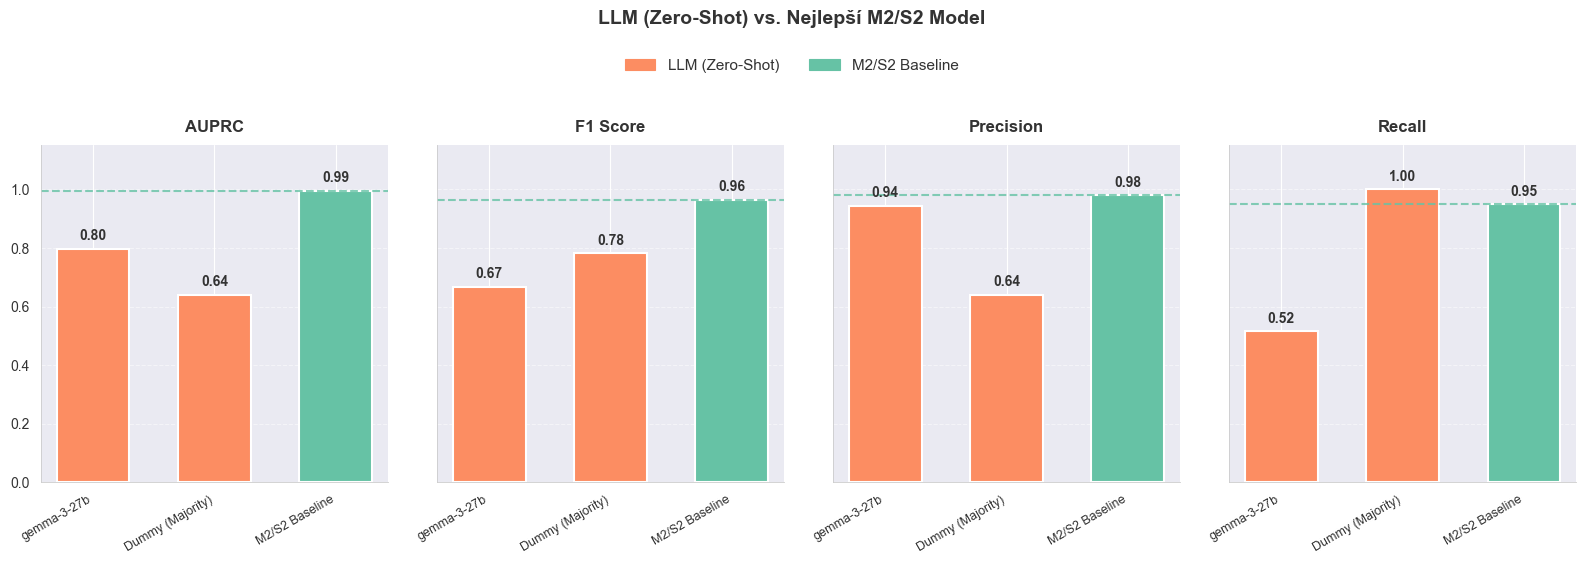

In [6]:
# ==========================================
# 1. Definice Baseline (Získání nejlepšího z M2_S2)
# ==========================================
results_filename = "M2_S2_experiment_results.csv" 
M2_S2_path = config.RESULTS_DIR / results_filename

TARGET_METRIC = 'test_auprc' 
HIGHER_IS_BETTER = True 

try:
    # Načtení výsledků
    df_m2_results = pd.read_csv(M2_S2_path)
    
    # Chytrá kontrola existence sloupce
    if TARGET_METRIC not in df_m2_results.columns:
        if f'test_{TARGET_METRIC}' in df_m2_results.columns:
            TARGET_METRIC = f'test_{TARGET_METRIC}'
        else:
            raise ValueError(f"Metrika '{TARGET_METRIC}' nebyla nalezena. Dostupné: {df_m2_results.columns.tolist()}")

    # Výběr nejlepšího modelu a PŘEVOD na DataFrame (to frame .T) pro vizualizační funkci
    if HIGHER_IS_BETTER:
        df_m2_best = df_m2_results.loc[df_m2_results[TARGET_METRIC].idxmax()].to_frame().T
    else:
        df_m2_best = df_m2_results.loc[df_m2_results[TARGET_METRIC].idxmin()].to_frame().T

    # Přejmenování sloupce s názvem modelu, aby mu vizualizace rozuměla
    if 'model_name' in df_m2_best.columns:
        df_m2_best = df_m2_best.rename(columns={'model_name': 'model'})

    print(f"✅ Baseline Model (z M2/S2) úspěšně nalezen!")
    print(f"🏆 Model: {df_m2_best['model'].iloc[0]} | {TARGET_METRIC}: {df_m2_best[TARGET_METRIC].iloc[0]:.4f}")

    # ==========================================
    # 2. Vykreslení grafu LLM vs M2/S2
    # ==========================================
    # Metriky, které chceme ukázat (přidána i accuracy, protože ji máš spočítanou)
    metrics_to_plot = ['auprc', 'f1', 'precision', 'recall', 'accuracy']
    
    # Pojistka: vykreslíme jen ty, co LLM reálně spočítalo
    metrics_to_plot = [m for m in metrics_to_plot if m in df_llm_metrics.columns]

    print("\n📊 Vykresluji porovnání...")
    visualization.plot_llm_vs_m2_comparison(
        df_llm_metrics=df_llm_metrics,
        df_m2_best=df_m2_best,
        metrics=metrics_to_plot,
        save_path=config.RESULTS_DIR / "M3_LLM_vs_M2_plot.png"
    )

except FileNotFoundError:
    print(f"❌ Chyba: Soubor s výsledky nebyl nalezen na cestě: {M2_S2_path}")
except Exception as e:
    print(f"❌ Došlo k chybě: {e}")

## 5. Deep Dive: Best LLM Model

🏆 Best LLM Model (by AUPRC): gemma-3-27b


2026-03-13 11:18:11,441 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S2_confusion_matrix_norm.png


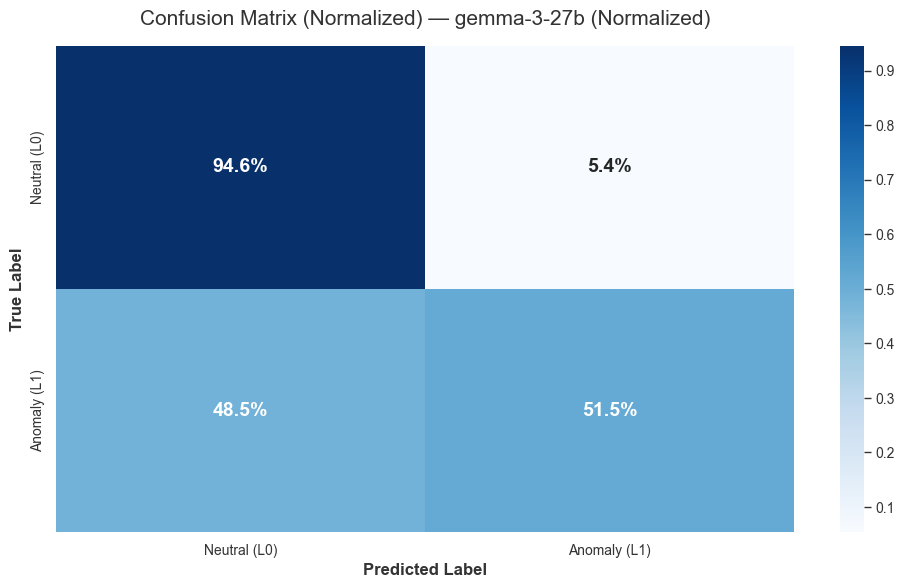

2026-03-13 11:18:11,911 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S2_confusion_matrix.png


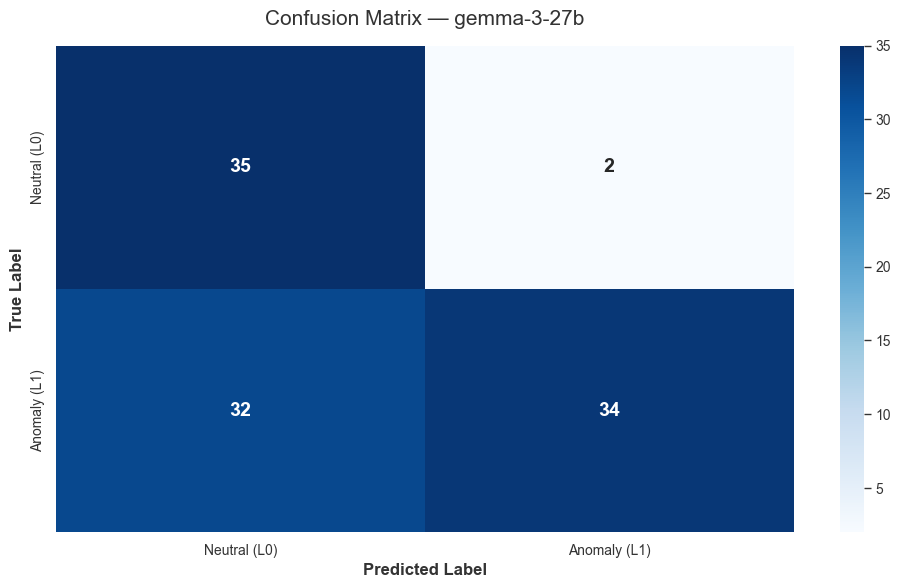

              precision    recall  f1-score   support

 Neutral (0)       0.52      0.95      0.67        37
    Bias (1)       0.94      0.52      0.67        66

    accuracy                           0.67       103
   macro avg       0.73      0.73      0.67       103
weighted avg       0.79      0.67      0.67       103



In [7]:
# ==========================================
# Výběr nejlepšího LLM modelu podle AUPRC
# ==========================================
best_llm_name = df_llm_metrics.loc[df_llm_metrics['auprc'].idxmax(), 'model']
best_llm_col = f"pred_{best_llm_name}"

print(f"🏆 Best LLM Model (by AUPRC): {best_llm_name}")

y_true = df_results['true_label'].astype(int).values
y_pred = df_results[best_llm_col].astype(int).values

# ==========================================
# Confusion Matrix (Normalized + Raw)
# ==========================================
visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=True,
    title=f"Confusion Matrix (Normalized) — {best_llm_name}",
    save_path=config.RESULTS_DIR / "M3_S2_confusion_matrix_norm.png"
)

visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=False,
    title=f"Confusion Matrix — {best_llm_name}",
    save_path=config.RESULTS_DIR / "M3_S2_confusion_matrix.png"
)

print(classification_report(y_true, y_pred, target_names=['Neutral (0)', 'Bias (1)']))

### Embedding Projections (Error Analysis)

Vizualizace chyb LLM modelu v embedding prostoru (mean pooling). Použijeme PCA a t-SNE projekci testovacích embeddingů, obarvenou podle kategorie predikce (TP, FP, TN, FN).

2026-03-13 11:18:20,880 - INFO - 1️⃣ Computing PCA...
2026-03-13 11:18:20,907 - INFO - 2️⃣ Computing t-SNE...


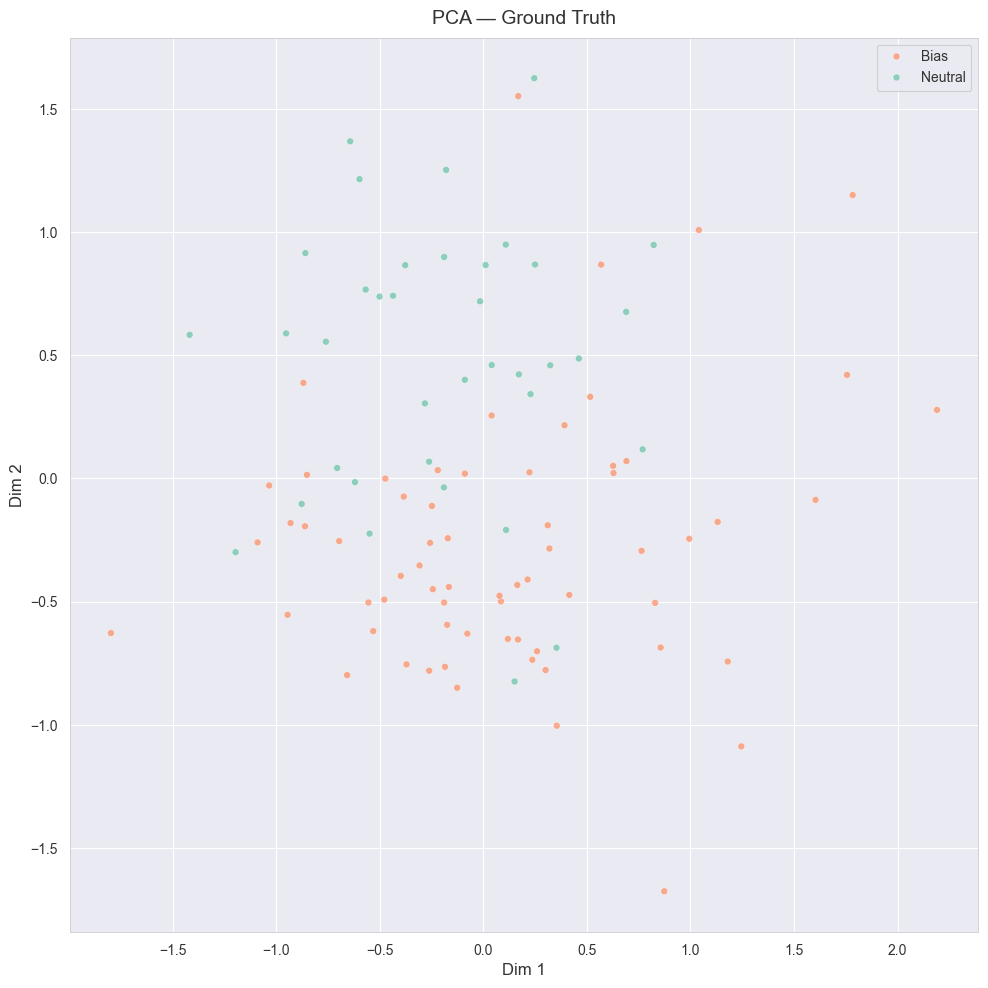

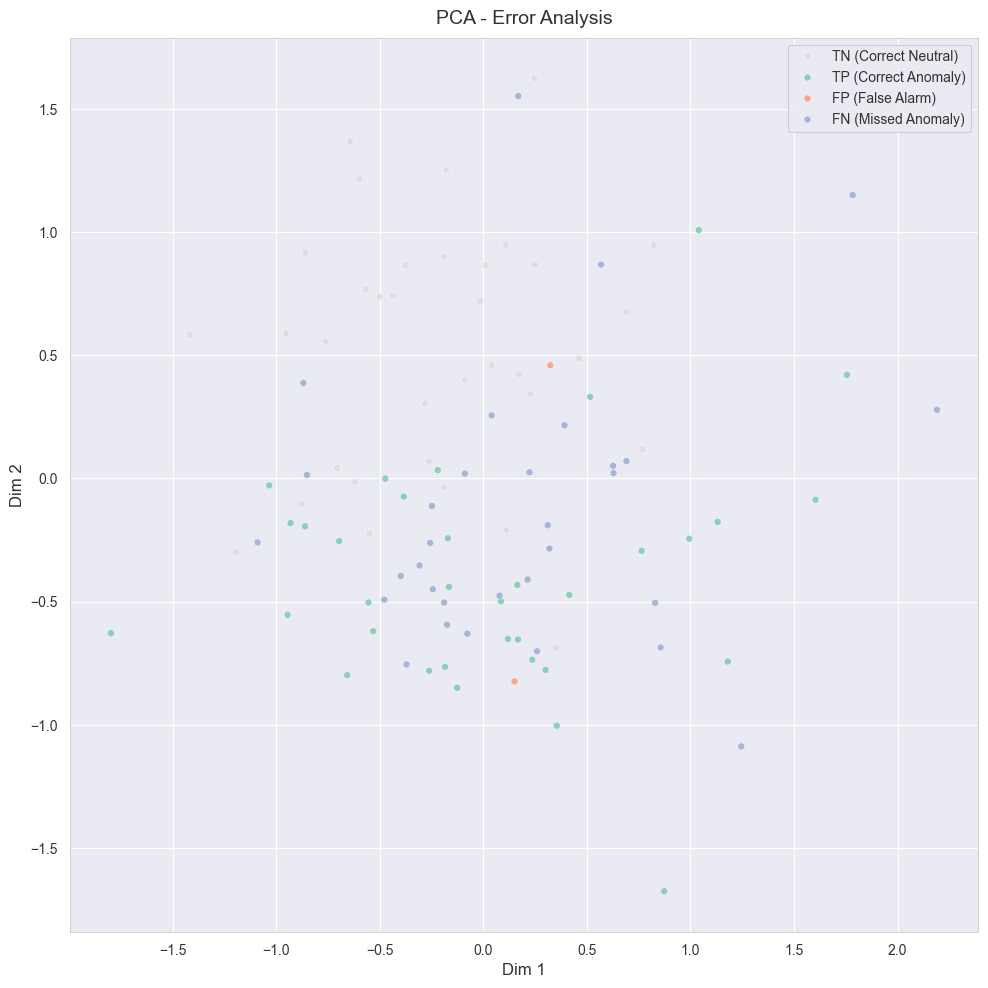

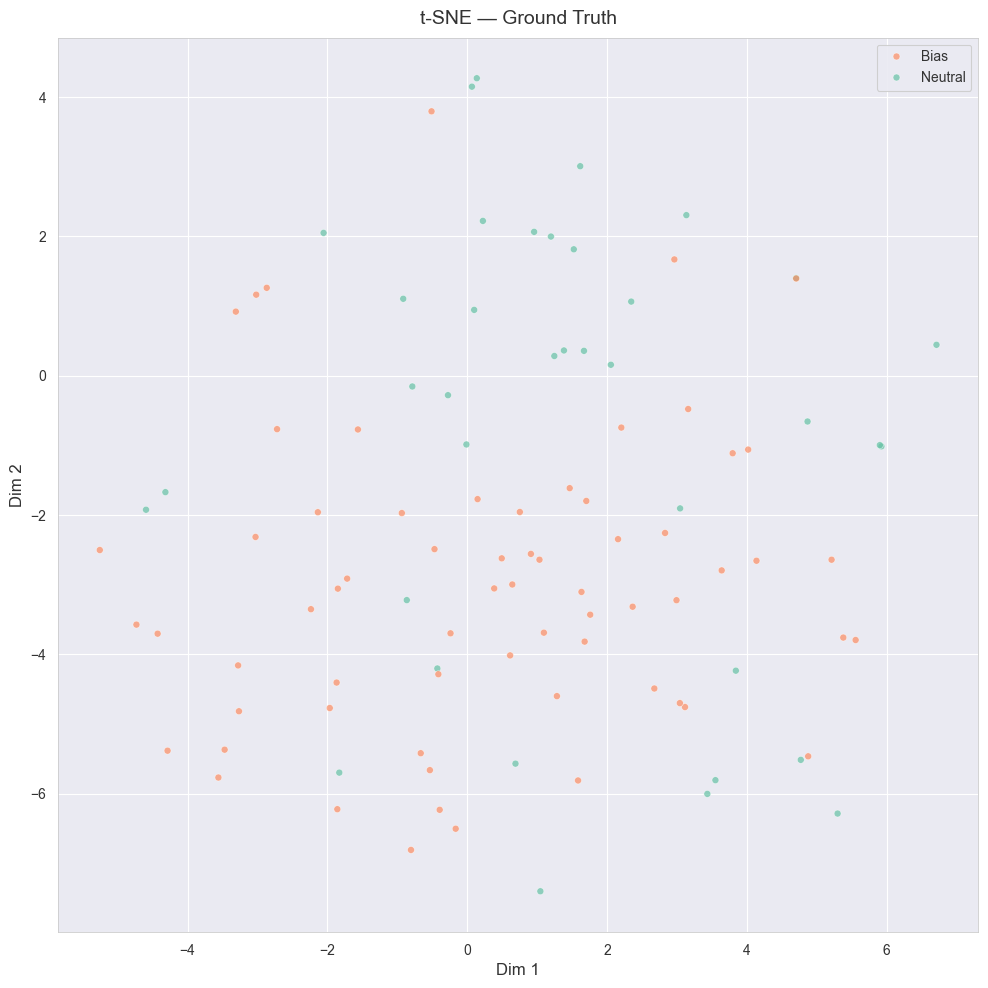

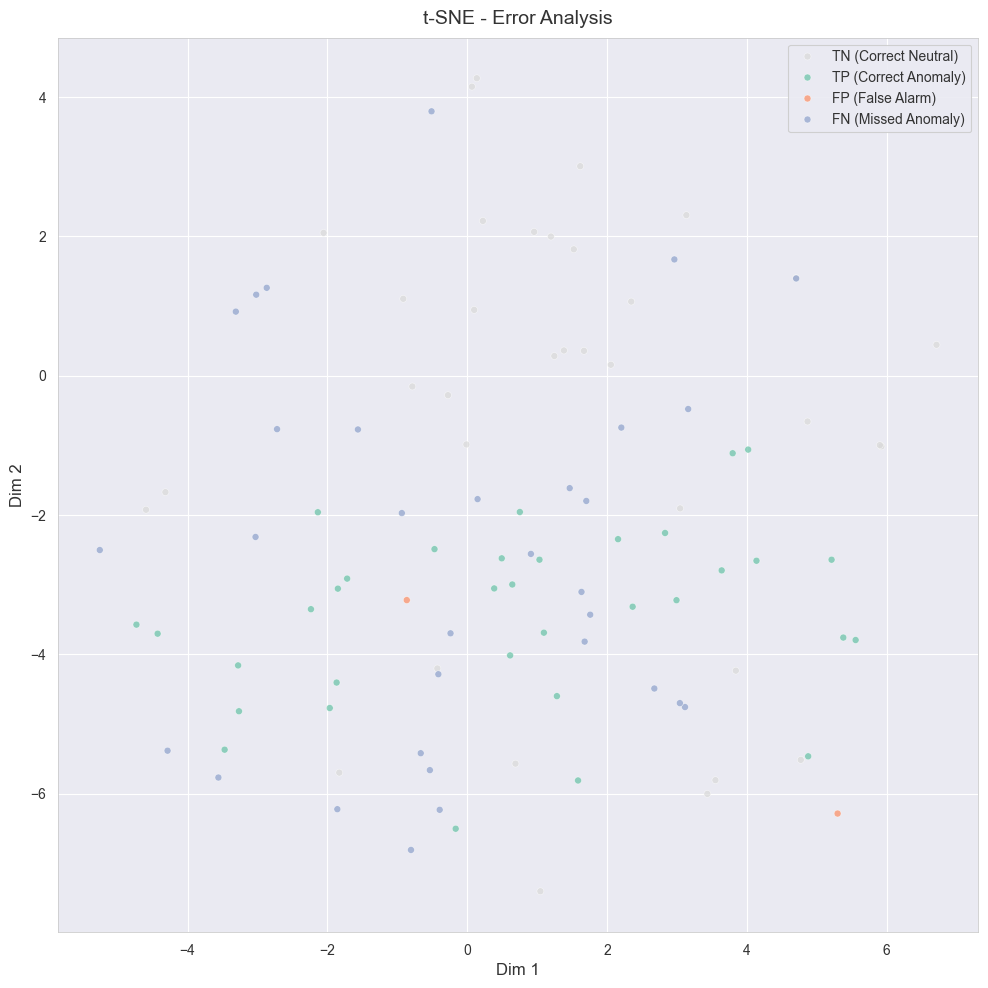

In [8]:
# ==========================================
# Embedding Projections — Error Analysis
# ==========================================
X_test = data['X_test']

# Compute PCA + t-SNE projections
projs, idxs = visualization.compute_projections(
    X_test, methods=['PCA', 't-SNE'], random_state=42
)

y_viz = y_true[idxs]
y_pred_viz = y_pred[idxs]

for method_name, coords in projs.items():
    # Ground Truth projection
    visualization.plot_embedding_projection(
        coords,
        pd.Series(y_viz).map({0: 'Neutral', 1: 'Bias'}),
        palette={'Neutral': config.COLORS['l0'], 'Bias': config.COLORS['l1']},
        title=f"{method_name} — Ground Truth",
        save_path=config.RESULTS_DIR / f"M3_S2_{method_name}_ground_truth.png"
    )
    
    # Error Analysis projection (TP, FP, TN, FN)
    visualization.plot_error_analysis_projection(
        coords, y_viz, y_pred_viz,
        method_name=method_name,
        save_path=config.RESULTS_DIR / f"M3_S2_{method_name}_error_analysis.png"
    )

## 6. Qualitative Analysis (Error Analysis)

Konkrétní příklady vět, které model nesprávně klasifikoval — False Positives (falešný poplach) a False Negatives (přehlédnutý bias).

In [9]:
# ==========================================
# Qualitative Error Analysis
# ==========================================
df_qual = data['meta_test'].copy()
df_qual['true_label'] = y_true
df_qual['pred_label'] = y_pred

# Kategorizace predikce (TP / TN / FP / FN)
conds = [
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 0),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 0),
]
df_qual['category'] = np.select(conds, ['TP', 'TN', 'FP', 'FN'], default='UNKNOWN')

# Seřazení sloupců
preferred_cols = ['document_id', 'sentence_id', 'text', 'true_label', 'pred_label', 'category']
final_cols = [c for c in preferred_cols if c in df_qual.columns]
remaining_cols = [c for c in df_qual.columns if c not in final_cols]
df_qual = df_qual[final_cols + remaining_cols]

# Distribuce kategorií
print("📊 Distribuce kategorií predikce:")
display(df_qual['category'].value_counts().to_frame('count'))

# --- False Positives ---
df_fp = df_qual[df_qual['category'] == 'FP']
print(f"\n❌ FALSE POSITIVES — Model viděl bias, kde není ({len(df_fp)} vět):")
display(df_fp[['document_id', 'text']].head(10))

# --- False Negatives ---
df_fn = df_qual[df_qual['category'] == 'FN']
print(f"\n❌ FALSE NEGATIVES — Model přehlédl bias ({len(df_fn)} vět):")
display(df_fn[['document_id', 'text']].head(10))

# Uložení do CSV
qual_path = config.RESULTS_DIR / "M3_S2_Qualitative_Analysis.csv"
df_qual.to_csv(qual_path, index=False)
print(f"\n💾 Qualitative analysis uložena: {qual_path}")

📊 Distribuce kategorií predikce:


,count
category,
TN,35
TP,34
FN,32
FP,2



❌ FALSE POSITIVES — Model viděl bias, kde není (2 vět):


,document_id,text
825,gold_doc_0276,"Poté , co v pondělí uvolnilo vstupenky na pros..."
1260,gold_doc_0421,"Výnosy jsou letos průměrné , kvalita je dobrá ."



❌ FALSE NEGATIVES — Model přehlédl bias (32 vět):


,document_id,text
165,gold_doc_0056,"Dodal , že firma se chce zaměřit na jednání s ..."
210,gold_doc_0071,"Komisař potvrdil , že auto jelo asi sto třicet..."
216,gold_doc_0073,Kritizované podmínky splnilo skoro všech pět z...
228,gold_doc_0077,"Opravdu šlo o tu chodbu , která byla u východu..."
249,gold_doc_0084,Stále nedořešená je otázka pendlerů a jejich z...
261,gold_doc_0088,Růst cen energií se zastavil a nastoupila nová...
270,gold_doc_0091,Byl zjištěn nečekaný případ inkongruence nález...
360,gold_doc_0121,"Byly nalezeny desítky artefaktů , které pocház..."
363,gold_doc_0122,Nové opatření se týká bezmála všech velkých in...
681,gold_doc_0228,Kolej Nepomucenum slouží studentům teologie a ...



💾 Qualitative analysis uložena: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S2_Qualitative_Analysis.csv
